# v1 (First Attempt): Predicting "Mostly Positive" Reviews on Steam

**This is the first version of the classification project, kept in the repo to show the iteration.** It predicts whether a game clears a single review-score threshold (`pct_pos_total >= 70`, Steam's own "Mostly Positive" cutoff) from structured attributes: price, achievements, playtime, platform support, and peak concurrent users.

**Result: weak.** ROC-AUC of 0.591 barely better than random guessing with the model heavily over-predicting the negative class once class weighting was applied to compensate for the 72%/28% imbalance.

**Why it's here:** the weak result led directly to the refined **[hit classification model](steam_games_hit_classification.ipynb)**, which sharpens the target into a rarer, less ambiguous label (top quartile of *both* review quality and review volume) and nearly doubles the improvement over a random baseline. See the main [README](README.md) for the full before/after comparison.


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, roc_curve, confusion_matrix, ConfusionMatrixDisplay,
    classification_report
)

sns.set_theme(style="whitegrid")


In [ ]:
import kagglehub
path = kagglehub.dataset_download("artermiloff/steam-games-dataset")
print("Path to dataset files:", path)

df1 = pd.read_csv(f"{path}/games_march2025_cleaned.csv")
df1.shape


Using Colab cache for faster access to the 'steam-games-dataset' dataset.
Path to dataset files: /kaggle/input/steam-games-dataset


(89618, 47)

In [ ]:
mask_positive = df1['pct_pos_total'] > -1
df = df1[mask_positive].copy()

df['windows'] = df['windows'].astype(int)
df['mac'] = df['mac'].astype(int)
df['linux'] = df['linux'].astype(int)

df['required_age'] = df['required_age'].replace(-1, 0)

print(f"Rows after cleaning: {len(df):,}")


Rows after cleaning: 53,199


## 3. Create the binary target

mostly_positive
1    38314
0    14885
Name: count, dtype: int64

mostly_positive
1    72.0
0    28.0
Name: proportion, dtype: float64


/tmp/ipykernel_873/3726931468.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='mostly_positive', data=df, palette=['#d9534f', '#5cb85c'])


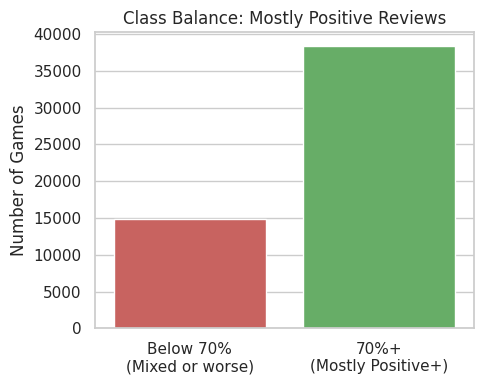

In [ ]:
df['mostly_positive'] = (df['pct_pos_total'] >= 70).astype(int)

class_counts = df['mostly_positive'].value_counts()
class_pct = df['mostly_positive'].value_counts(normalize=True) * 100

print(class_counts)
print()
print(class_pct.round(1))

plt.figure(figsize=(5, 4))
sns.countplot(x='mostly_positive', data=df, palette=['#d9534f', '#5cb85c'])
plt.xticks([0, 1], ['Below 70%\n(Mixed or worse)', '70%+\n(Mostly Positive+)'])
plt.title('Class Balance: Mostly Positive Reviews')
plt.ylabel('Number of Games')
plt.xlabel('')
plt.tight_layout()
plt.show()


In [ ]:
feature_cols = [
    'required_age',
    'price',
    'discount',
    'achievements',
    'average_playtime_forever',
    'median_playtime_forever',
    'peak_ccu',
    'num_reviews_total',
    'windows',
    'mac',
    'linux',
]

model_df = df[feature_cols + ['mostly_positive']].dropna()

X = model_df[feature_cols]
y = model_df['mostly_positive']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"Train size: {X_train.shape[0]:,} | Test size: {X_test.shape[0]:,}")


Train size: 42,559 | Test size: 10,640


In [ ]:
log_reg = LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42)
log_reg.fit(X_train_scaled, y_train)

y_pred = log_reg.predict(X_test_scaled)
y_proba = log_reg.predict_proba(X_test_scaled)[:, 1]


## 6. Evaluate

In [ ]:
acc = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred)
rec = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
auc = roc_auc_score(y_test, y_proba)

print(f"Accuracy:  {acc:.3f}")
print(f"Precision: {prec:.3f}")
print(f"Recall:    {rec:.3f}")
print(f"F1 score:  {f1:.3f}")
print(f"ROC-AUC:   {auc:.3f}")
print()
print(classification_report(y_test, y_pred, target_names=['Below 70%', 'Mostly Positive+']))


Accuracy:  0.469
Precision: 0.807
Recall:    0.345
F1 score:  0.484
ROC-AUC:   0.591

                  precision    recall  f1-score   support

       Below 70%       0.32      0.79      0.45      2977
Mostly Positive+       0.81      0.35      0.48      7663

        accuracy                           0.47     10640
       macro avg       0.56      0.57      0.47     10640
    weighted avg       0.67      0.47      0.48     10640



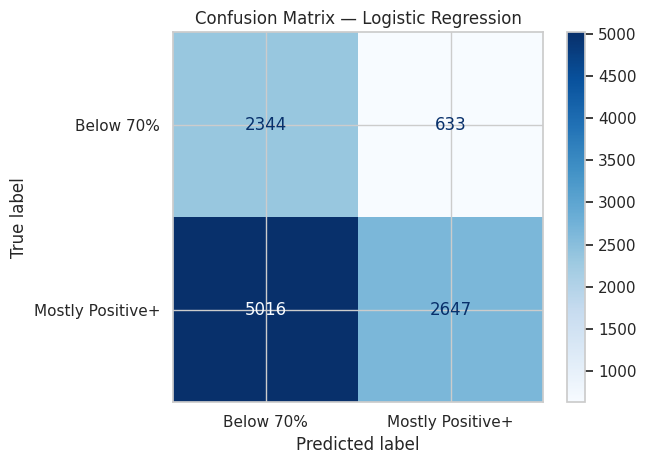

In [ ]:
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Below 70%', 'Mostly Positive+'])
disp.plot(cmap='Blues', values_format='d')
plt.title('Confusion Matrix — Logistic Regression')
plt.tight_layout()
plt.show()


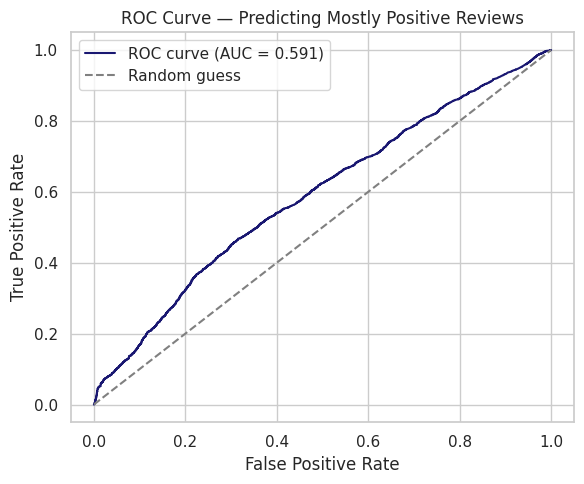

In [ ]:
fpr, tpr, _ = roc_curve(y_test, y_proba)

plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, color='#191771', label=f'ROC curve (AUC = {auc:.3f})')
plt.plot([0, 1], [0, 1], linestyle='--', color='gray', label='Random guess')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve — Predicting Mostly Positive Reviews')
plt.legend()
plt.tight_layout()
plt.show()


                 feature  coefficient  odds_ratio
       num_reviews_total     1.374007    3.951149
average_playtime_forever     0.382434    1.465848
 median_playtime_forever     0.194406    1.214589
                     mac     0.120544    1.128111
                   linux     0.086799    1.090678
                   price     0.039822    1.040625
                 windows     0.035952    1.036606
                discount     0.007225    1.007251
            achievements    -0.015683    0.984439
            required_age    -0.044846    0.956145
                peak_ccu    -0.835696    0.433573


/tmp/ipykernel_873/787892115.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=coef_df, x='coefficient', y='feature', palette='coolwarm')


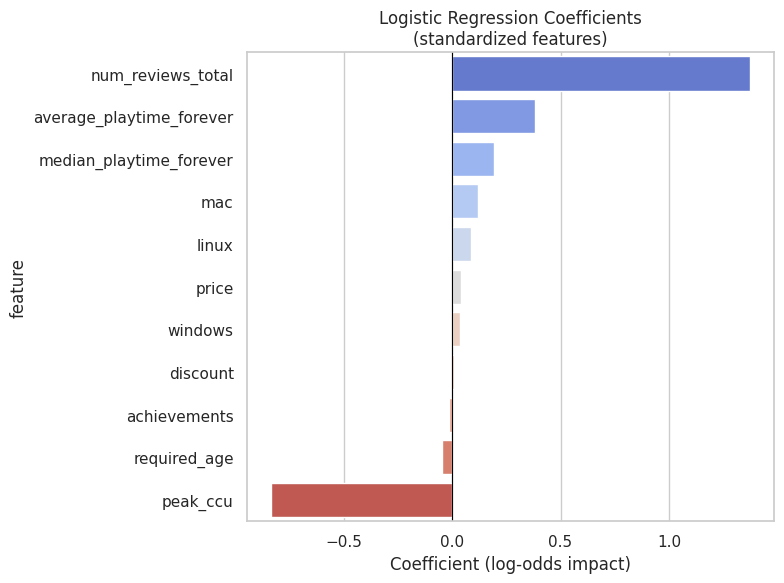

In [ ]:
coef_df = pd.DataFrame({
    'feature': feature_cols,
    'coefficient': log_reg.coef_[0],
})
coef_df['odds_ratio'] = np.exp(coef_df['coefficient'])
coef_df = coef_df.sort_values('coefficient', ascending=False)

print(coef_df.to_string(index=False))

plt.figure(figsize=(8, 6))
sns.barplot(data=coef_df, x='coefficient', y='feature', palette='coolwarm')
plt.axvline(0, color='black', linewidth=0.8)
plt.title('Logistic Regression Coefficients\n(standardized features)')
plt.xlabel('Coefficient (log-odds impact)')
plt.tight_layout()
plt.show()


## Findings

- **ROC-AUC: 0.591** only marginally better than a coin flip at separating the two classes.
- **Accuracy: 0.469**, which is *worse* than the naive baseline of always predicting "Mostly Positive+" (which would score ~0.72, since that's the majority class in this framing).
- **Recall on the positive class: 0.345** with `class_weight='balanced'`, the model swung toward over-predicting "Below 70%," misclassifying the majority of true "Mostly Positive+" games in the process (see the confusion matrix above: 5,016 false negatives vs. 2,647 true positives).
- **The one genuinely useful signal:** `num_reviews_total` had by far the strongest positive coefficient (odds ratio ≈ 3.95) games with more total reviews were much more likely to be "Mostly Positive+," consistent with the "funnel effect" from the original EDA (low-review games are volatile in either direction; high-review games converge toward the market's overall positive skew).
- **The likely diagnosis:** a single 70% cutoff blurs together a game that just barely clears "Mostly Positive" with one that's universally beloved. The label itself is noisy, not just the features which motivated the redefinition in v2.

**Next step:** see [`steam_games_hit_classification.ipynb`](steam_games_hit_classification.ipynb) for the refined approach and stronger results.
